# Day 3 Exploratory Data Analysis (EDA)

## Setup: Required Libraries
The code below ensures that `kaleido` is installed in your active Jupyter kernel. Plotly requires this package to save charts as PNG images instead of HTML.

In [10]:
import sys
!{sys.executable} -m pip install -q kaleido


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Task 1: NAV Trend Analysis
- Plot daily NAV for all 40 schemes 2022-2026.
- Highlight COVID recovery, 2023 rally, 2024 corrections.

In [11]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# Robustly resolve project root regardless of whether Jupyter is running from /notebooks or the project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Build paths dynamically
nav_path = project_root / "data" / "processed" / "clean_nav.csv"
fund_master_path = project_root / "data" / "processed" / "clean_fund_master.csv"

# Load clean NAV and Fund Master data
nav_df = pd.read_csv(nav_path)
fund_master_df = pd.read_csv(fund_master_path)

# Convert date string to datetime object
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Merge with fund master to get the scheme name for each AMFI code
nav_merged = pd.merge(nav_df, fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Ensure data is sorted chronologically
nav_merged = nav_merged.sort_values(by='date')

nav_merged.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
28944,119120,2022-01-03,42.1391,SBI Magnum Gilt Fund - Regular Plan - Growth
27336,119095,2022-01-03,52.5238,Axis Small Cap Fund - Regular - Growth
25728,119094,2022-01-03,68.3023,Axis Midcap Fund - Regular - Growth
24120,119093,2022-01-03,41.8140,Axis Bluechip Fund - Direct - Growth


In [12]:
# Plotting absolute daily NAV for all 40 schemes using Plotly
fig = px.line(
    nav_merged, 
    x='date', 
    y='nav', 
    color='scheme_name', 
    title='Daily NAV Trend for 40 Mutual Fund Schemes (2022-2026)',
    labels={'nav': 'Net Asset Value (INR)', 'date': 'Date', 'scheme_name': 'Scheme Name'}
)

# Add highlighted regions for major market events
# 1. COVID recovery (Early 2022)
fig.add_vrect(
    x0='2022-01-01', x1='2022-04-30', 
    fillcolor='green', opacity=0.1, line_width=0,
    annotation_text='COVID Recovery', annotation_position='top left'
)

# 2. 2023 Rally (Mid to late 2023)
fig.add_vrect(
    x0='2023-04-01', x1='2023-12-31', 
    fillcolor='blue', opacity=0.1, line_width=0,
    annotation_text='2023 Rally', annotation_position='inside top left'
)

# 3. 2024 Corrections (Early to Mid 2024)
fig.add_vrect(
    x0='2024-01-01', x1='2024-06-30', 
    fillcolor='red', opacity=0.1, line_width=0,
    annotation_text='2024 Corrections', annotation_position='top right'
)

# Enhance layout for publication quality
fig.update_layout(
    xaxis=dict(showgrid=True, title='Date'),
    yaxis=dict(
        showgrid=True, 
        title='NAV (Log Scale)',
        type='log'
    ),
    showlegend=False,
    template='plotly_white',
    height=800,
    hovermode='x unified'
)

# Save the chart as PNG only (converted path to string to prevent older Plotly version errors)
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
fig.write_image(str(reports_dir / "nav_trend.png"), width=1200, height=800, scale=2)

fig.show()

## Task 2: AUM Growth Bar Chart
- Grouped bar chart: AUM by fund house for each year 2022-2025.
- Highlight SBI's dominance at Rs.12.5L Cr.

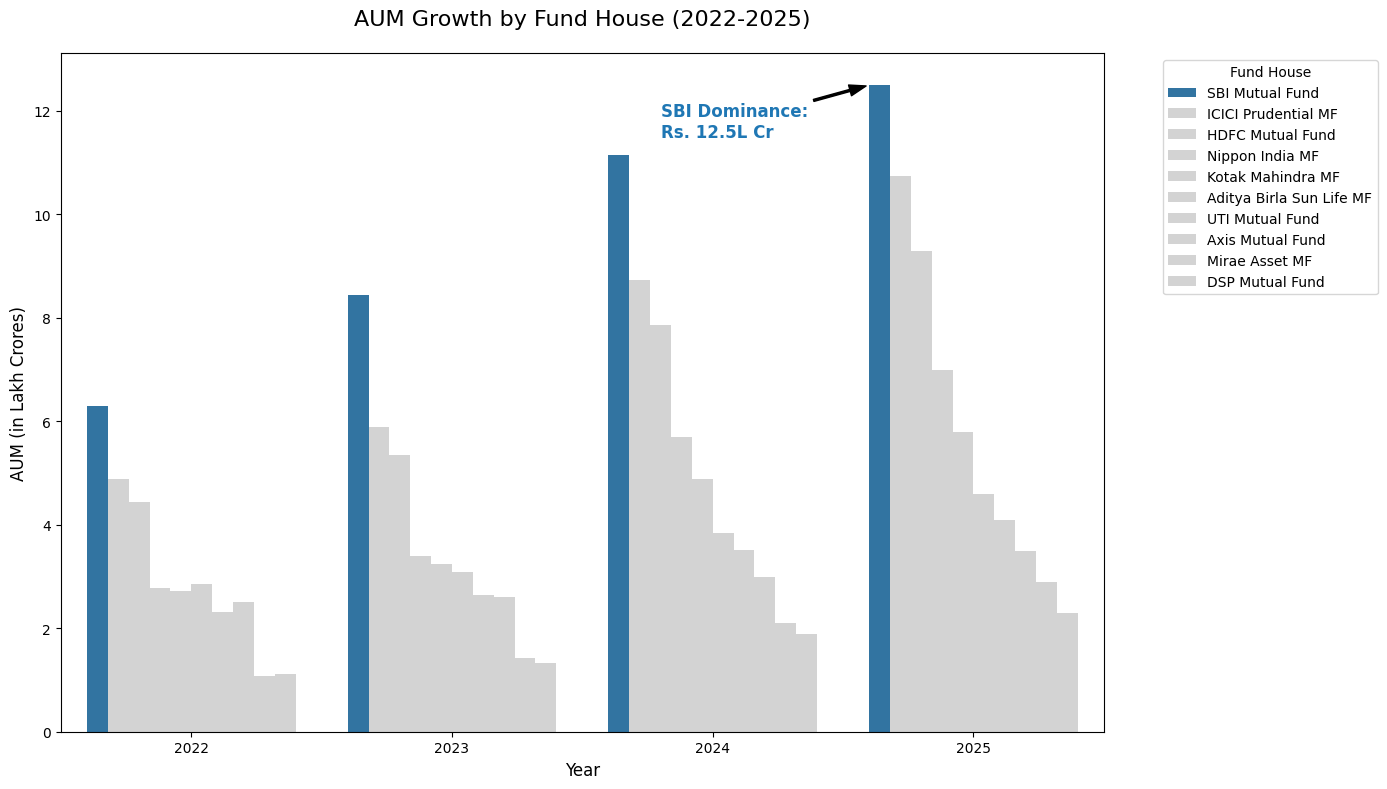

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Load AUM data
aum_path = project_root / "data" / "processed" / "clean_aum_by_fund_house.csv"
aum_df = pd.read_csv(aum_path)

# Extract year from date
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

# Get max AUM per year per fund house
aum_yearly = aum_df.groupby(['year', 'fund_house'])['aum_lakh_crore'].max().reset_index()

# Sort to have SBI Mutual Fund distinct and keep top funds
top_funds = aum_yearly[aum_yearly['year'] == 2025].sort_values(by='aum_lakh_crore', ascending=False)['fund_house'].tolist()

# Define custom color palette
custom_palette = {fund: '#1f77b4' if fund == 'SBI Mutual Fund' else '#d3d3d3' for fund in top_funds}

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=aum_yearly, 
    x='year', 
    y='aum_lakh_crore', 
    hue='fund_house',
    hue_order=top_funds,
    palette=custom_palette
)

plt.title("AUM Growth by Fund House (2022-2025)", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("AUM (in Lakh Crores)", fontsize=12)

# Highlight SBI's 12.5L Cr dominance
plt.annotate(
    "SBI Dominance:\nRs. 12.5L Cr", 
    xy=(2.6, 12.5), 
    xytext=(1.8, 11.5),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=12,
    fontweight='bold',
    color='#1f77b4'
)

plt.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the chart
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
plt.savefig(reports_dir / "aum_growth_by_amc.png", dpi=300, bbox_inches='tight')

plt.show()

## Task 3: SIP Inflow Trend
- Plotly line chart of Monthly SIP inflow (Jan 2022 - Dec 2025)
- Mark the Rs.31,002 Cr milestone (Dec 2025).

In [14]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Load SIP inflow data
sip_path = project_root / "data" / "processed" / "clean_monthly_sip_inflows.csv"
sip_df = pd.read_csv(sip_path)

# Ensure month column is datetime for proper plotting
sip_df['month'] = pd.to_datetime(sip_df['month'])

# Create Plotly line chart
fig_sip = px.line(
    sip_df, 
    x='month', 
    y='sip_inflow_crore', 
    title='Monthly SIP Inflow Trend (2022-2025)',
    labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (Rs. Crore)'},
    markers=True
)

# Mark the Rs. 31,002 Cr milestone (Dec 2025)
fig_sip.add_annotation(
    x='2025-12-01', 
    y=31002,
    text="Milestone: Rs. 31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    ax=-80,
    ay=-50,
    font=dict(color="green", size=14),
    arrowcolor="green"
)

fig_sip.update_layout(
    template='plotly_white',
    hovermode='x unified'
)

# Save the chart as PNG only (converted path to string to prevent older Plotly version errors)
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
fig_sip.write_image(str(reports_dir / "sip_inflow_trend.png"), width=1000, height=600, scale=2)

fig_sip.show()

## Task 4: Category-wise Inflow Heatmap
- Months on X-axis, categories on Y-axis, net inflow as colour intensity.
- Seaborn heatmap.

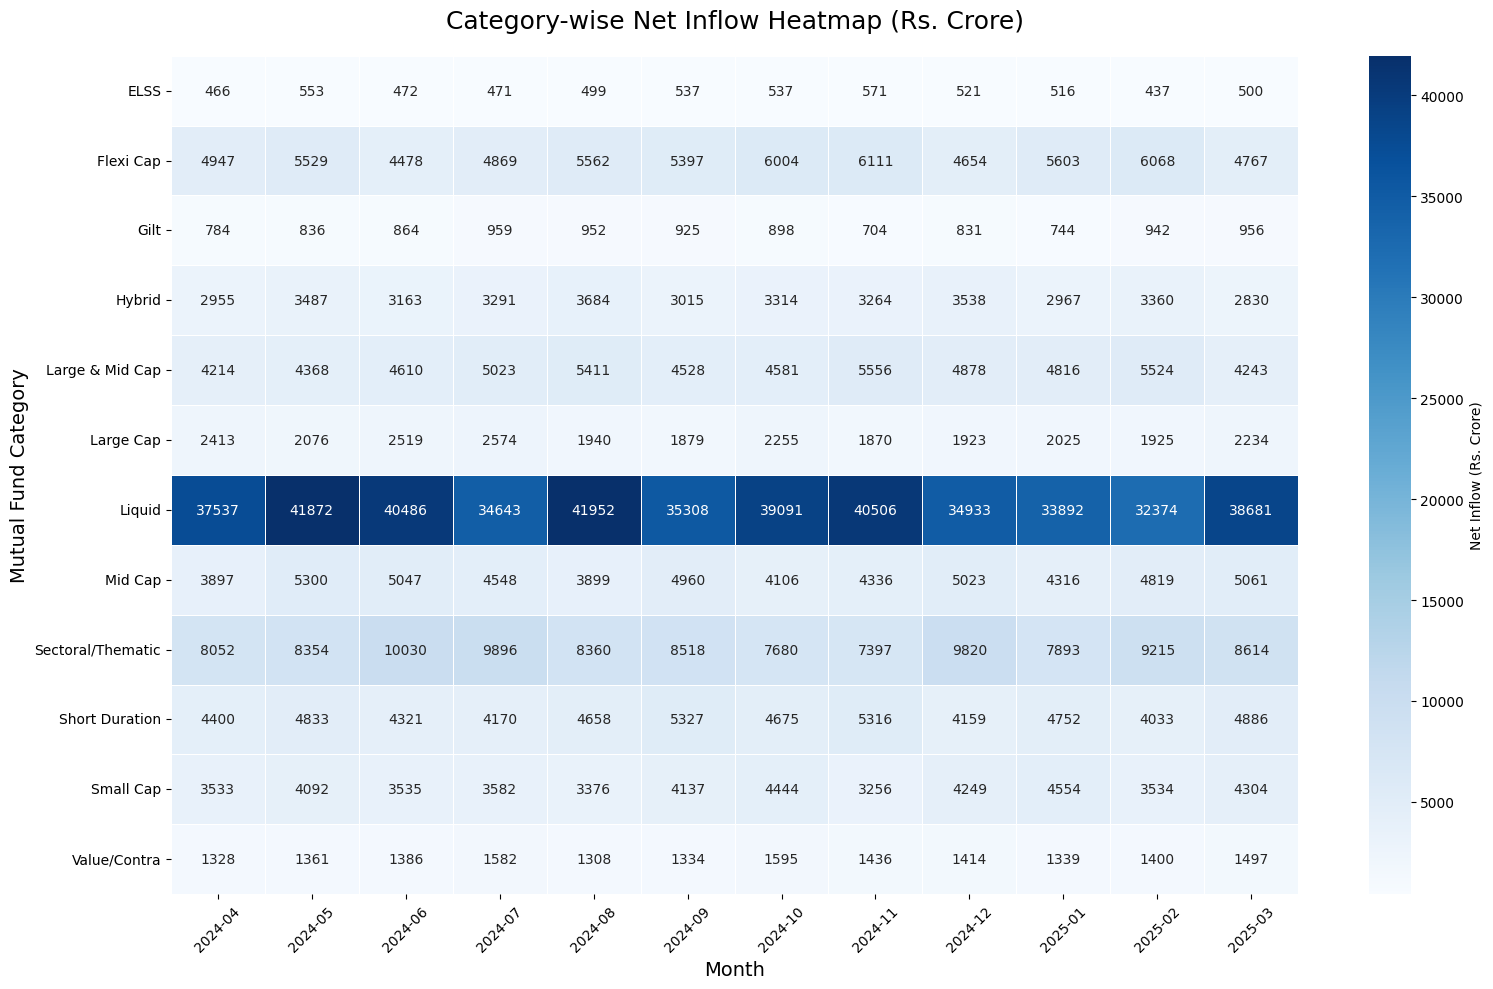

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Load category inflow data
category_path = project_root / "data" / "processed" / "clean_category_inflows.csv"
category_df = pd.read_csv(category_path)

# Pivot the data: Months on X-axis (columns), Categories on Y-axis (index), net inflow as values
heatmap_data = category_df.pivot(index='category', columns='month', values='net_inflow_crore')

# Set up the matplotlib figure
plt.figure(figsize=(16, 10))

# Plot heatmap using Seaborn
# Using 'Blues' cmap where darker means more inflow
sns.heatmap(
    heatmap_data, 
    cmap='Blues', 
    annot=True,     # Show numbers in cells
    fmt=".0f",      # Format as integers
    linewidths=.5,
    cbar_kws={'label': 'Net Inflow (Rs. Crore)'}
)

plt.title('Category-wise Net Inflow Heatmap (Rs. Crore)', fontsize=18, pad=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Mutual Fund Category', fontsize=14)

# Rotate X-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()

# Save the chart
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
plt.savefig(reports_dir / "category_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

## Task 5: Investor Demographics
- Age group distribution pie chart.
- SIP amount box plot by age group.

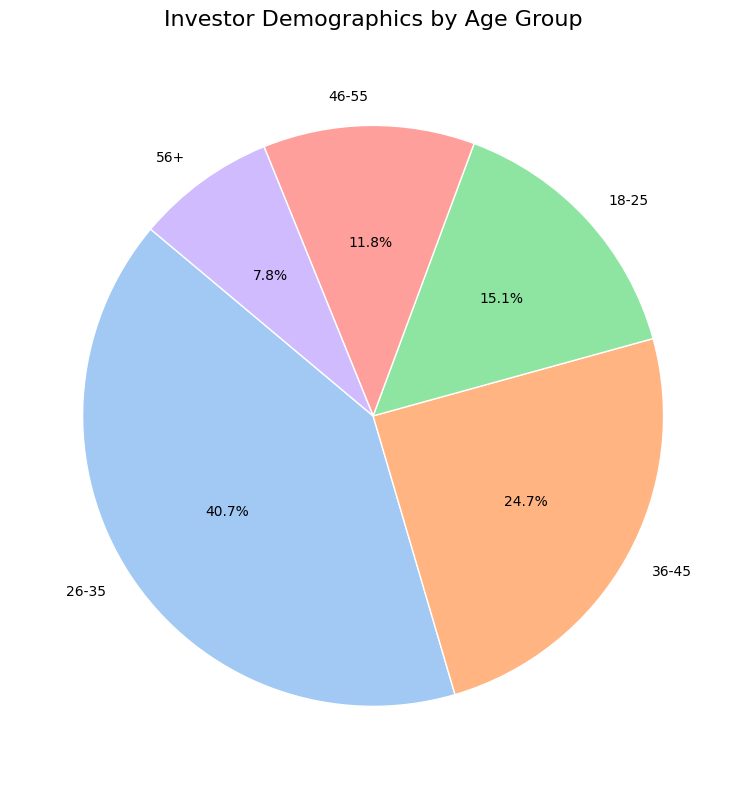

C:\Users\nindr\AppData\Local\Temp\ipykernel_19060\885611617.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


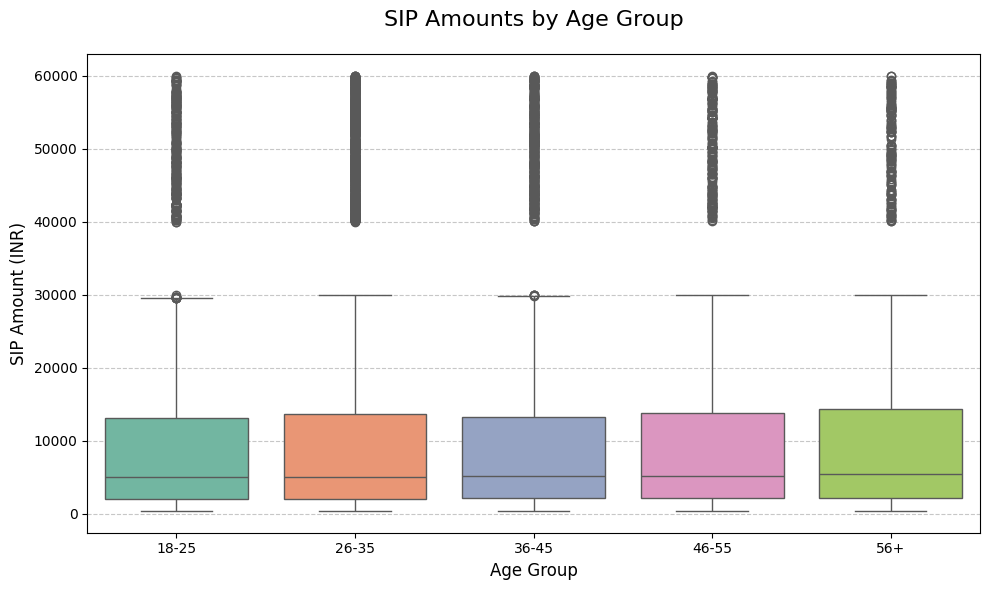

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Load transactions data
transactions_path = project_root / "data" / "processed" / "clean_transactions.csv"
tx_df = pd.read_csv(transactions_path)

reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)

### Chart 1: Age Group Pie Chart ###
# Get unique investors to calculate true demographics
unique_investors = tx_df.drop_duplicates(subset=['investor_id'])
age_counts = unique_investors['age_group'].value_counts()

# Define a nice color palette for the pie chart
colors = sns.color_palette('pastel')[0:len(age_counts)]

plt.figure(figsize=(8, 8))
plt.pie(
    age_counts, 
    labels=age_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    wedgeprops={'edgecolor': 'white'}
)
plt.title("Investor Demographics by Age Group", fontsize=16, pad=20)
plt.tight_layout()
# Save Chart 1
plt.savefig(reports_dir / "age_group_pie_chart.png", dpi=300, bbox_inches='tight')
plt.show()

### Chart 2: SIP Amount Box Plot ###
# Filter only SIP transactions
sip_tx = tx_df[tx_df['transaction_type'] == 'SIP'].copy()

plt.figure(figsize=(10, 6))
# Create box plot using Seaborn
sns.boxplot(
    data=sip_tx, 
    x='age_group', 
    y='amount_inr', 
    palette='Set2',
    order=['18-25', '26-35', '36-45', '46-55', '56+'] # Logical age order
)

plt.title("SIP Amounts by Age Group", fontsize=16, pad=20)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("SIP Amount (INR)", fontsize=12)

# Add gridlines for better readability of the box plot
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# Save Chart 2
plt.savefig(reports_dir / "sip_amount_box_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Task 6: Geographic Distribution
- Horizontal bar chart: SIP amount by state.
- Pie chart: T30 vs B30 SIP contributions.

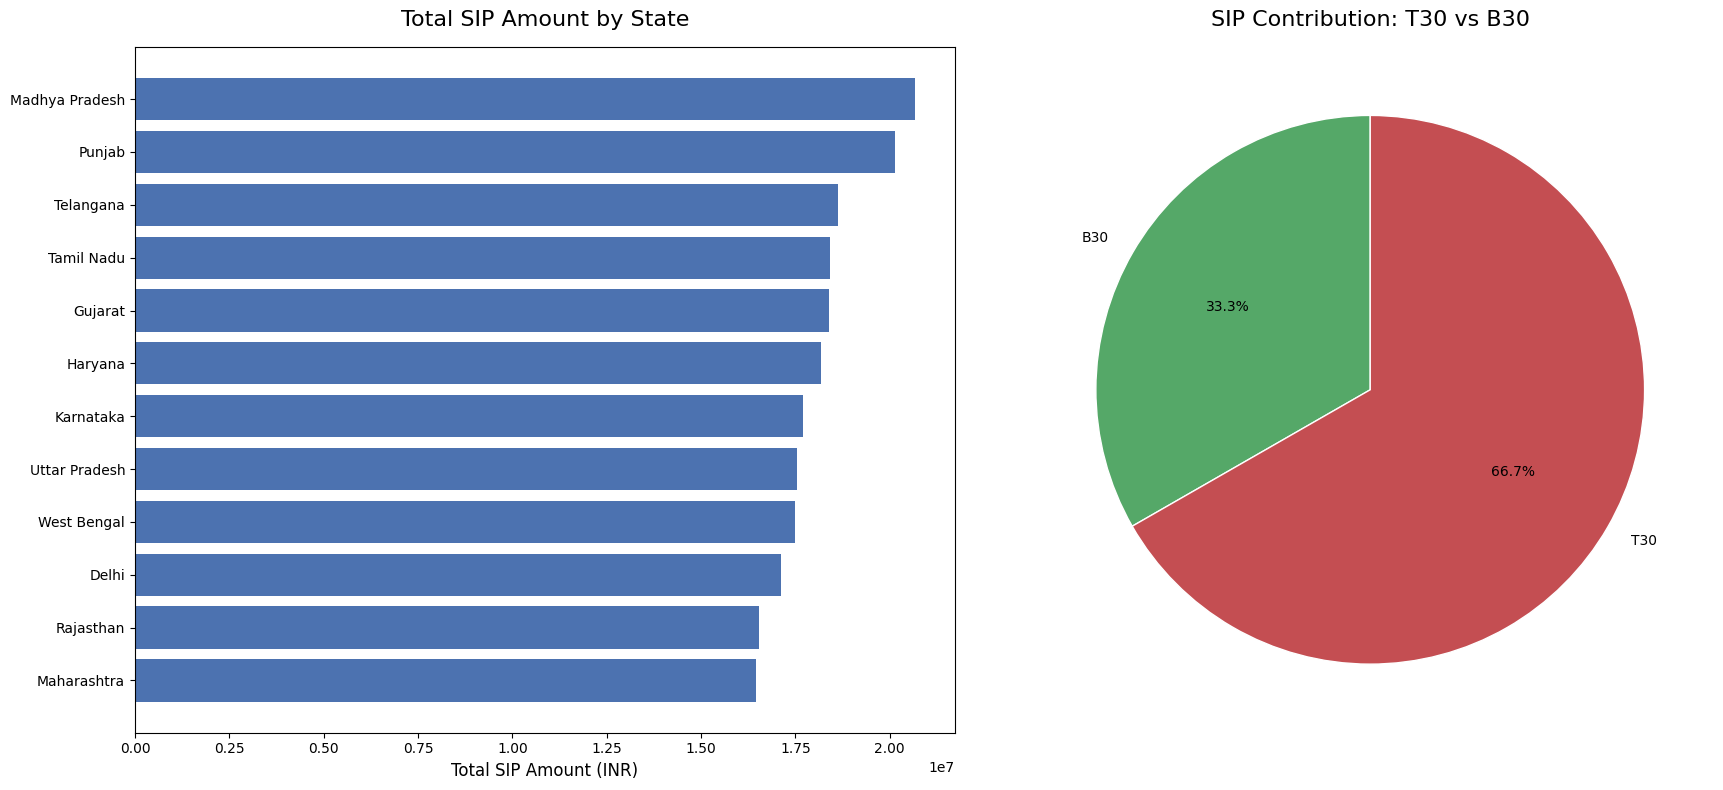

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Load transactions data
transactions_path = project_root / "data" / "processed" / "clean_transactions.csv"
tx_df = pd.read_csv(transactions_path)

# Filter for SIPs only
sip_df = tx_df[tx_df['transaction_type'] == 'SIP'].copy()

# Set up the figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

### Chart 1: SIP Amount by State (Horizontal Bar Chart) ###
state_sip = sip_df.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
axes[0].barh(state_sip.index, state_sip.values, color='#4c72b0')
axes[0].set_title("Total SIP Amount by State", fontsize=16, pad=15)
axes[0].set_xlabel("Total SIP Amount (INR)", fontsize=12)

### Chart 2: T30 vs B30 Pie Chart ###
city_tier_sip = sip_df.groupby('city_tier')['amount_inr'].sum()
axes[1].pie(
    city_tier_sip, 
    labels=city_tier_sip.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#55a868', '#c44e52'], 
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title("SIP Contribution: T30 vs B30", fontsize=16, pad=15)

plt.tight_layout()

# Save as PNG only
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
plt.savefig(reports_dir / "geo_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## Task 7: Folio Count Growth
- Line chart showing folio growth from Jan 2022 to Dec 2025.

In [18]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Load folio count data
folio_path = project_root / "data" / "processed" / "clean_industry_folio_count.csv"
folio_df = pd.read_csv(folio_path)

folio_df['month'] = pd.to_datetime(folio_df['month'])

# Plotly line chart
fig_folio = px.line(
    folio_df, 
    x='month', 
    y='total_folios_crore', 
    title='Mutual Fund Industry Folio Growth (2022-2025)',
    labels={'month': 'Date', 'total_folios_crore': 'Total Folios (in Crores)'},
    markers=True
)

# Add annotation for the start
fig_folio.add_annotation(
    x='2022-01-01', 
    y=13.26,
    text="13.26 Crore",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40,
    font=dict(size=12)
)

# Add annotation for the end
fig_folio.add_annotation(
    x='2025-12-01', 
    y=26.12,
    text="26.12 Crore",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=40,
    font=dict(color="green", size=14)
)

fig_folio.update_layout(template='plotly_white')

# Save as PNG only (converted path to string to prevent older Plotly version errors)
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
fig_folio.write_image(str(reports_dir / "folio_growth.png"), width=1000, height=600, scale=2)

fig_folio.show()

## Task 8: Correlation Matrix (NAV Returns)
- Compute pairwise correlation of NAV returns across 10 selected funds.
- Seaborn heatmap.

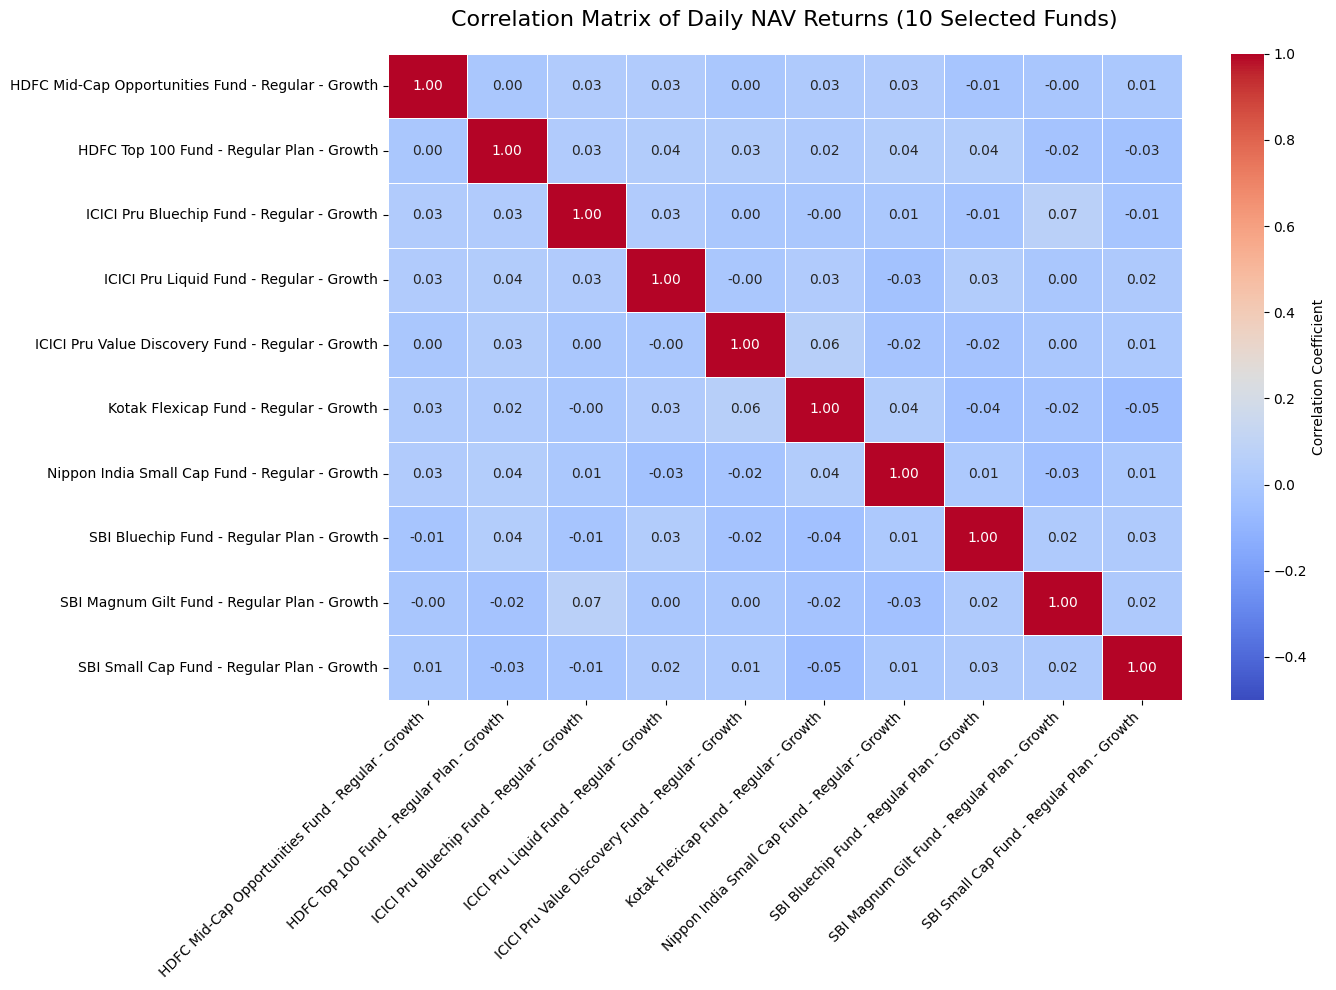

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

nav_path = project_root / "data" / "processed" / "clean_nav.csv"
fund_master_path = project_root / "data" / "processed" / "clean_fund_master.csv"

nav_df = pd.read_csv(nav_path)
fund_master_df = pd.read_csv(fund_master_path)

nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_merged = pd.merge(nav_df, fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Select our 10 strategic funds
selected_funds = [
    'SBI Bluechip Fund - Regular Plan - Growth',
    'HDFC Top 100 Fund - Regular Plan - Growth',
    'ICICI Pru Bluechip Fund - Regular - Growth',
    'SBI Small Cap Fund - Regular Plan - Growth',
    'Nippon India Small Cap Fund - Regular - Growth',
    'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
    'Kotak Flexicap Fund - Regular - Growth',
    'ICICI Pru Value Discovery Fund - Regular - Growth',
    'SBI Magnum Gilt Fund - Regular Plan - Growth',
    'ICICI Pru Liquid Fund - Regular - Growth'
]

# Filter for the selected funds
nav_10 = nav_merged[nav_merged['scheme_name'].isin(selected_funds)].copy()

# Pivot so dates are index and scheme names are columns
nav_pivot = nav_10.pivot(index='date', columns='scheme_name', values='nav')

# Calculate daily percentage returns (and drop the first NaN row)
returns = nav_pivot.pct_change().dropna()

# Calculate the correlation matrix
corr_matrix = returns.corr()

# Draw the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-0.5, 
    vmax=1.0, 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Selected Funds)", fontsize=16, pad=20)
plt.xlabel("")
plt.ylabel("")

# Rotate x-axis labels slightly for better fit
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Save chart
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
plt.savefig(reports_dir / "correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

## Task 9: Sector Allocation (Top Holdings)
- Donut chart of sector weights across all equity fund portfolios.

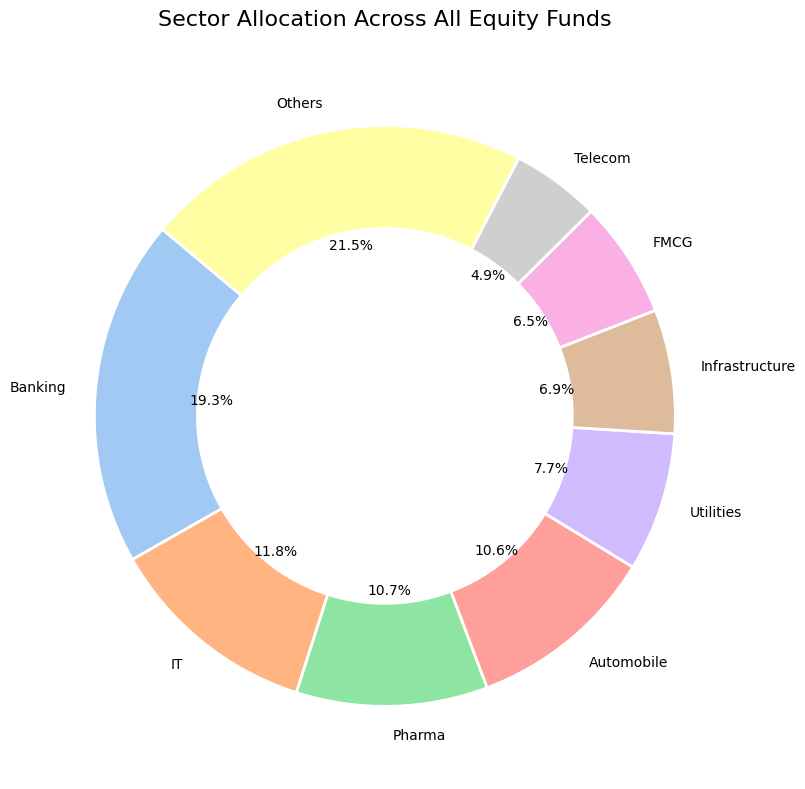

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Robustly resolve project root
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

# Load portfolio holdings and fund master
holdings_path = project_root / "data" / "processed" / "clean_portfolio_holdings.csv"
holdings_df = pd.read_csv(holdings_path)

fund_master_path = project_root / "data" / "processed" / "clean_fund_master.csv"
fund_master_df = pd.read_csv(fund_master_path)

# Filter to only include Equity funds
equity_funds = fund_master_df[fund_master_df['category'] == 'Equity']['amfi_code']
equity_holdings = holdings_df[holdings_df['amfi_code'].isin(equity_funds)]

# Calculate total market value per sector across the entire equity industry
sector_weights = equity_holdings.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False)

# Take top 8 sectors, group the rest into 'Others' for a clean chart
top_sectors = sector_weights.head(8)
others_value = sector_weights.iloc[8:].sum()
if others_value > 0:
    top_sectors['Others'] = others_value

# Draw the Donut Chart
plt.figure(figsize=(10, 8))

colors = sns.color_palette('pastel')[0:len(top_sectors)]

# Plot the pie
plt.pie(
    top_sectors, 
    labels=top_sectors.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Draw a white circle at the center to create the "donut" hole
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across All Equity Funds", fontsize=16, pad=20)
plt.tight_layout()

# Save chart
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
plt.savefig(reports_dir / "sector_allocation.png", dpi=300, bbox_inches='tight')
plt.show()